#### Loading SMS Dataset and Preprocessing data using NLP, Regular Expressions, and Training and Testing Machine Learning Algorithms such as Logistics Regression, Naive Bayes, Random Forest, and Support Vector Machine

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sms_data = pd.read_csv(r"C:\Users\vasil\OneDrive\ScamLens Dissertation\ScamLens Project\data\cleaned\sms_cleaned.csv")

In [3]:
sms_data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
sms_data.info

<bound method DataFrame.info of      label                                            message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
...    ...                                                ...
5164  spam  This is the 2nd time we have tried 2 contact u...
5165   ham              Will Ì_ b going to esplanade fr home?
5166   ham  Pity, * was in mood for that. So...any other s...
5167   ham  The guy did some bitching but I acted like i'd...
5168   ham                         Rofl. Its true to its name

[5169 rows x 2 columns]>

In [5]:
sms_data.columns

Index(['label', 'message'], dtype='object')

#### The sms_cleaned file was clean and loaded for preprocessing and applying Regular Expressions. The sms_data dataset contains 5169 rows and 2 columns such as 'label'- represented ham and spam labels, and 'message'- represented text columns with messages.

In [6]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#### Stop words remover was applied to remove the noises from the text column as removed the words such as 'and, if, the, a, and and so on'. This will be help the machine learning algorithms to focus on importance in the text colimn.

#### WordNetLemmatizer is used to return the word in its base form such as if the text has word ' bought ' the lemmatizer will return to the base form of 'buy'. This will reduce the vocabulary size, improve consistency and performance of the machine learning algorithms.

In [7]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

#### Regular Expression for cleaning the text; r''-row string, http-looks for text starting with http, \S- any characters that is not a space, +- one or more occurrences, |- means OR, \d- means nubers from 0-9, []- characters set, ^- Means NOT, a-z- lowercase letters, A-Z - uppercase letters, \s - nay whitespace character, \s+ - means maches. 

In [8]:
# This function convert everything in lower case.
def convert_lowercase(text):
    text = text.lower()
    return text

In [9]:
# This function replace and keep the nuber with 'NUMBER' instead to removed.
def replace_numbers(text):
    text = re.sub(r'\d+', 'NUMBER',text)
    return text

In [10]:
# This function remove special characters, will remove everything which is not a letter 'a-z, A-Z, and spaces.
def remove_special_characters(text):
    text = re.sub(r'[^a-zA-Z\s]','',text)
    return text

In [11]:
#This function remove the unnecessary spaces in the text.
def remove_extra_spaces(text):
    text = re.sub(r'\s+', ' ', text)
    return text

In [12]:
# This function replace the link URL with 'URL' without remove it.
def replace_links(text):
    text = re.sub(r'https\S+|www\S+', 'URL', text)
    return text

In [13]:
# This function replace the email with the word 'EMAIL' instead removing it.
def replace_emails(text):
    text = re.sub(r'\S+@\S+', 'EMAIL',text)
    return text

In [14]:
"""This function split the sentence into individual words,
check if the word belong to the stop-word list, 
using for na dif conditions, At the end the function return jioned words in one sentence."""
def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

In [15]:
"""This function create a object and convert the word in base form using for in condition, 
add together in one sentence."""
def lemmatize_text(text):
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(words)

In [16]:
# Creating one main function and adding all separated functions for preprocessing text in one place.
def clean_sms_text(text):
    text = convert_lowercase(text)
    text = replace_numbers(text)
    text = remove_special_characters(text)
    text = remove_extra_spaces(text)
    text = replace_links(text)
    text = replace_emails(text)
    text = lemmatize_text(text)
    text = remove_stopwords(text)
    return text

#### Creating a new column and applying the function to clean the text. After that we have a third column with clean and preprocessing text.

In [17]:
sms_data['clean_message'] = sms_data['message'].apply(clean_sms_text)

In [18]:
sms_data.head()

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry NUMBER wkly comp win fa cup final t...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


#### Spliting the dataset into 'X' nad 'y' applying and defining the new text cleaned column as features and label column as labels.

In [19]:
X = sms_data['clean_message']
y = sms_data['label']

In [20]:
sms_data[['message','clean_message']].head(30)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry NUMBER wkly comp win fa cup final t...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling NUMBER week word back id l...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile NUMBER month u r entitled update latest...


#### The cleaned dataset was divided into training and testing sets 80/20 as training set contains 4135 rows, the testing set contains 1034 rows. We use random_state=42 to keep the same random_state every time when is  used. Stratify = y , is used to maintain the same distribution of ham amd spam messages.

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state=42, stratify = y)

In [23]:
print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 4135
Testing samples: 1034


#### TF-IDF Vectorizer was used to convert the text into numerical vectors. TF or Terms Frequency measure how often the word appear in the text, IDF or Inverse Document Frequency measure the word appearnce in the entire document or dataset. In the X_train set is used fit_transform, while in the X_test is used only the transform to prevent of data leaking from the X_test set.

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

In [25]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [26]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(4135, 6951)
(1034, 6951)


# Applying Naive Bayes Algorithm

In [27]:
from sklearn.naive_bayes import MultinomialNB

In [28]:
nb_model = MultinomialNB()

In [29]:
nb_model.fit(X_train_tfidf,y_train)

MultinomialNB()

In [30]:
y_pred = nb_model.predict(X_test_tfidf)

In [31]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)

#### The Multinomial Naive Bayes model achieved accuracy of 96%, with an excellent precision of 99%. However, the spam reccal was 72%, which means some of the messages were not detected as Spam and were classified as Ham.

In [32]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       0.99      0.72      0.83       131

    accuracy                           0.96      1034
   macro avg       0.98      0.86      0.91      1034
weighted avg       0.96      0.96      0.96      1034



In [33]:
from sklearn.metrics import confusion_matrix
sms = confusion_matrix(y_test,y_pred)
print(sms)

[[902   1]
 [ 37  94]]


 #### Naive Bayes algoritm correctly specified 902Ham messages and 94 for Spam, however; 37 messages were wrong specified as Ham messages.

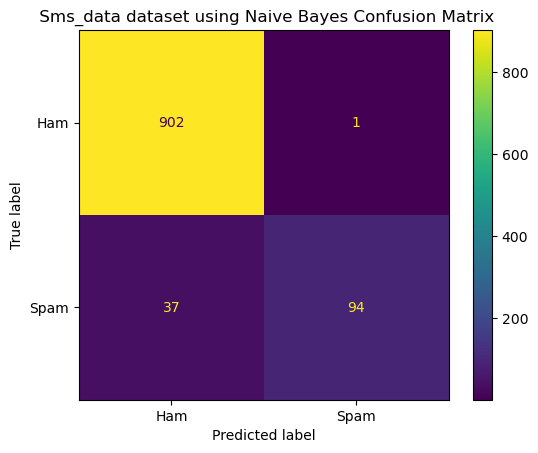

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels = ['Ham','Spam']
)
plt.title(' Sms_data dataset using Naive Bayes Confusion Matrix' )
plt.show()

# Applying Logistic Regression Algorithm

In [35]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter = 1000)

lr_model.fit(X_train_tfidf,y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

#### Logistic Regression achieved accuracy of 97%, with precision of 96% and recall of 79%. Compared to the Naive Bayes model, Logistic Regression demonstrated improved recall  and F1 score values. However, some spam message were still incorrectly classified as Ham messages.

In [36]:
from sklearn.metrics import accuracy_score, classification_report

lr_accuracy = accuracy_score(y_test,y_pred_lr)

print('Logistic Regression Accuracy:',lr_accuracy)
print(classification_report(y_test,y_pred_lr))                             
                            

Logistic Regression Accuracy: 0.9700193423597679
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       903
        spam       0.96      0.79      0.87       131

    accuracy                           0.97      1034
   macro avg       0.97      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034



#### Logistic Regression Matrix plot exposed improvement of recall of the Spam message than Naive Bayes. The Logistic Regression was wrong classified only 27  Ham messages as Spam amd 4 Spam messages as Ham.

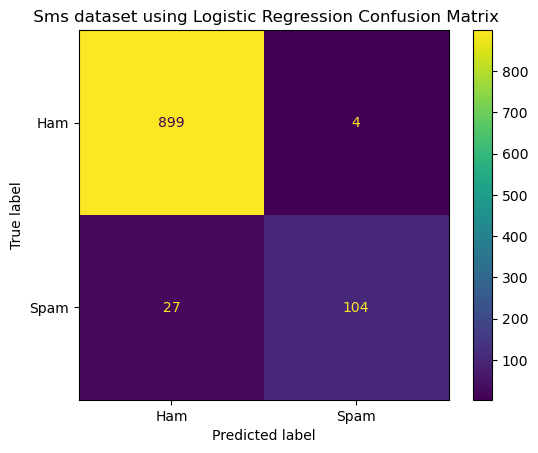

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels = ['Ham','Spam']
)
plt.title(' Sms dataset using Logistic Regression Confusion Matrix' )
plt.show()

# Applying Support Vector Machine Algorithm

In [38]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
base_svm = LinearSVC()
svm_model = CalibratedClassifierCV(base_svm, cv = 5)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

#### Support Vector Machine model achieved accuracy of 98.26%, with a precision of 95% and recall of 91%. This result indicate that the model was able correctly identify the majority of spam messages compared to the Naive Bayes, and Logistic Regression models.

In [39]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print('SVM Accuracy:', svm_accuracy)
print(classification_report(y_test,y_pred_svm))

SVM Accuracy: 0.9845261121856866
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       903
        spam       0.95      0.93      0.94       131

    accuracy                           0.98      1034
   macro avg       0.97      0.96      0.96      1034
weighted avg       0.98      0.98      0.98      1034



#### Support Vector Machine displayed an excellent results as model wrong predicted 12 Ham messages as Sapm messages, and only 6 Spam messages were worng classified as Ham messages.

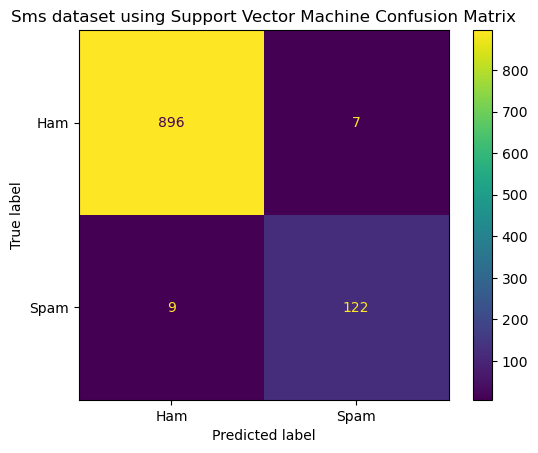

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels = ['Ham','Spam']
)
plt.title('Sms dataset using Support Vector Machine Confusion Matrix' )
plt.show()

# Applying Random Forest Algorithm

In [41]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators = 100, random_state =42)
rf_model.fit(X_train_tfidf,y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)

#### Random Forest achieved accuracy of 98.16, wirh precision pf 99% and recall of 86%. The model demonstrate that the model is highly effective of identification of Spam messages and maintained overall excellent classificatiom performance better than Naive Bayes, and Logistic Regression.

In [42]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print('Random Forest Accuracy:', rf_accuracy)
print(classification_report(y_test,y_pred_rf))


Random Forest Accuracy: 0.9816247582205029
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       903
        spam       0.99      0.86      0.92       131

    accuracy                           0.98      1034
   macro avg       0.99      0.93      0.96      1034
weighted avg       0.98      0.98      0.98      1034



#### Random Forest model was able to predict only 18 Ham messages wrong as Spam messages, and only 1 Spam message as Ham message. The model performed better than Naive Bayes - 37 wrong messages classified, and Logistic Regression - 27 worng messages were classified as Spam. Overall, the Support Vector Machine achieved the highest scores among Naive Bayes, Logistic Regression, and Random Forest.

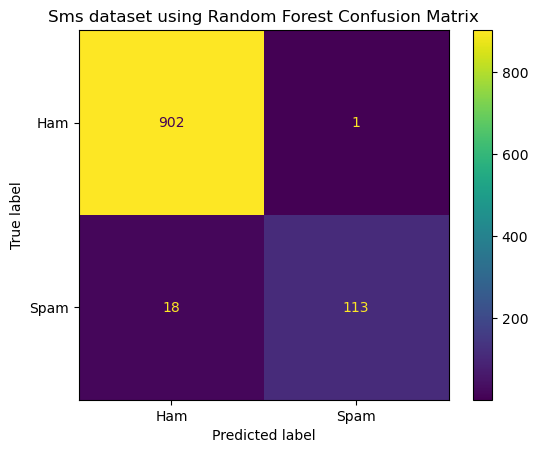

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels = ['Ham','Spam']
)
plt.title('Sms dataset using Random Forest Confusion Matrix' )
plt.show()

#### Comparison table of tested algorithms and achieved score

In [44]:
results = pd.DataFrame({
    'Model':['Naive Bayes','Logistic Regression','Support Vector Machine','Random Forest'],
    'Accuracy':[0.96,0.97,0.9826,0.9816],
    'Spam Recall':[0.72,0.79,0.91,0.86],
    'Spam F1':[0.83,0.87,0.93,0.92]
})

In [45]:
results

,Model,Accuracy,Spam Recall,Spam F1
0,Naive Bayes,0.9600,0.72,0.83
1,Logistic Regression,0.9700,0.79,0.87
2,Support Vector Machine,0.9826,0.91,0.93
3,Random Forest,0.9816,0.86,0.92


#### The SVM model was performed and achieved the best results and was saved in the models folder where the model will be used into ScamLens. Moreover, TF-IDF Vectorizer model was saved as well into models folder.

In [46]:
import joblib
joblib.dump(svm_model,'../models/sms_svm_model.pkl')

['../models/sms_svm_model.pkl']

In [47]:
joblib.dump(tfidf,'../models/sms_tfidf.pkl')

['../models/sms_tfidf.pkl']